# Training machine learning model for cellulose solubility in ionic liquids prediction

In [1]:
from tensorflow import keras
import tensorflow as tf
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import sklearn
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from rdkit.Chem import Descriptors
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import shap

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


## Training models on total dataset

1. Read dataset

In [2]:
df = pd.read_csv('dataset_for_cellulose_solubility_ML_model.csv')
smis = list(df.loc[:, 'smiles'])
cation = list(df.loc[:, 'cation'])
anion = list(df.loc[:, 'anion'])
Ts = list(df.loc[:, 'T'])
Crystal = list(df.loc[:, 'cellulose_crystal'])
Crystal_avicel = []
Crystal_MCC = []
Crystal_cellulose = []
for item in Crystal:
    if item == 'Avicel':
        Crystal_avicel.append(1)
        Crystal_MCC.append(0)
        Crystal_cellulose.append(0)
    
    elif item == 'MCC':
        Crystal_avicel.append(0)
        Crystal_MCC.append(1)
        Crystal_cellulose.append(0)
        
    elif item == 'cellulose':
        Crystal_avicel.append(0)
        Crystal_MCC.append(0)
        Crystal_cellulose.append(1)
        
heating_time = list(df.loc[:,'heating_time'])
Ys = list(df.loc[:, 'solv'])

2. Calculate descriptors

In [3]:
def getMolDescriptors(smi):
    mol = Chem.MolFromSmiles(smi)
    res = []
    for nm, fn in Descriptors._descList:
        res.append(fn(mol))
    return res
def smiles_to_MACCS(smi): 
    mol = Chem.MolFromSmiles(smi)
    fp = AllChem.GetMACCSKeysFingerprint(mol)
    fp = np.array(fp, float)
    return fp
Des_cation = np.array([getMolDescriptors(c) for c in cation])
Des_anion = np.array([getMolDescriptors(a) for a in anion])
fp_anion = np.array([smiles_to_MACCS(a) for a in anion])
fp_cation = np.array([smiles_to_MACCS(c) for c in cation])
fp_mol = np.array([smiles_to_MACCS(s) for s in smis])
X = np.c_[fp_cation, Des_cation, fp_anion, Des_anion, Ts, heating_time, Crystal_avicel, Crystal_MCC, Crystal_cellulose]
Y = np.array(Ys).reshape(len(Ys), 1)

3. Split traning set and testing set

In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

4. Random forest (RF) regression

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


R^2_test=0.664013
mse_test=17.359073


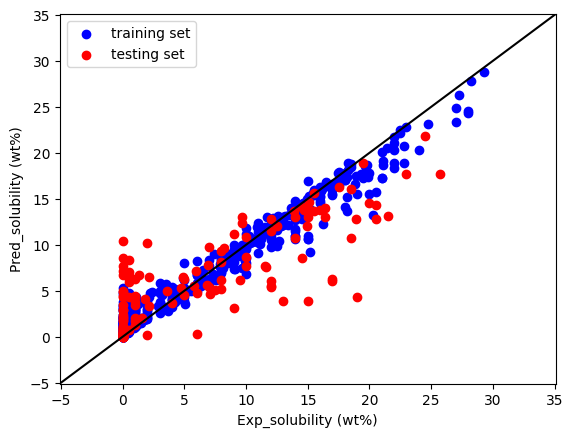

In [5]:
regr = RandomForestRegressor(random_state=1)
regr.fit(X_train, Y_train)
Y_test_pred = regr.predict(X_test)
Y_train_pred = regr.predict(X_train)
r2_test = sklearn.metrics.r2_score(Y_test, Y_test_pred)
r2_train = sklearn.metrics.r2_score(Y_train, Y_train_pred)
mse_test = mean_squared_error(Y_test, Y_test_pred)
plt.figure()
plt.xlabel("Exp_solubility (wt%)")
plt.ylabel("Pred_solubility (wt%)")
plt.plot([-5.1, 35.1], [-5.1, 35.1], c='black')
plt.scatter(Y_train, Y_train_pred, c='blue', label='training set')
plt.scatter(Y_test, Y_test_pred, c='red', label='testing set')
plt.xlim([-5.1, 35.1])
plt.ylim([-5.1, 35.1])
plt.legend()
print('R^2_test=%f'%r2_test)
print('mse_test=%f'%mse_test)

5. Extreme gradient boosting (XGBoost) regression

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().


R^2_test=0.583975
mse_test=21.494321


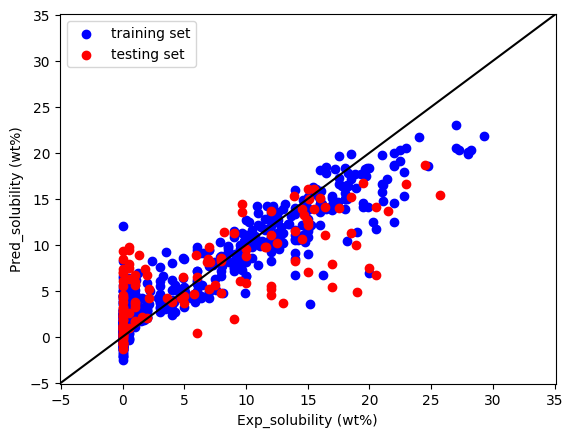

In [6]:
regr = GradientBoostingRegressor(random_state=1)
regr.fit(X_train, Y_train)
Y_test_pred = regr.predict(X_test)
Y_train_pred = regr.predict(X_train)
r2_test = sklearn.metrics.r2_score(Y_test, Y_test_pred)
r2_train = sklearn.metrics.r2_score(Y_train, Y_train_pred)
mse_test = mean_squared_error(Y_test, Y_test_pred)
plt.figure()
plt.xlabel("Exp_solubility (wt%)")
plt.ylabel("Pred_solubility (wt%)")
plt.plot([-5.1, 35.1], [-5.1, 35.1], c='black')
plt.scatter(Y_train, Y_train_pred, c='blue', label='training set')
plt.scatter(Y_test, Y_test_pred, c='red', label='testing set')
plt.xlim([-5.1, 35.1])
plt.ylim([-5.1, 35.1])
plt.legend()
print('R^2_test=%f'%r2_test)
print('mse_test=%f'%mse_test)

6. Ridge regression

R^2_test=0.396607
mse_test=31.174870


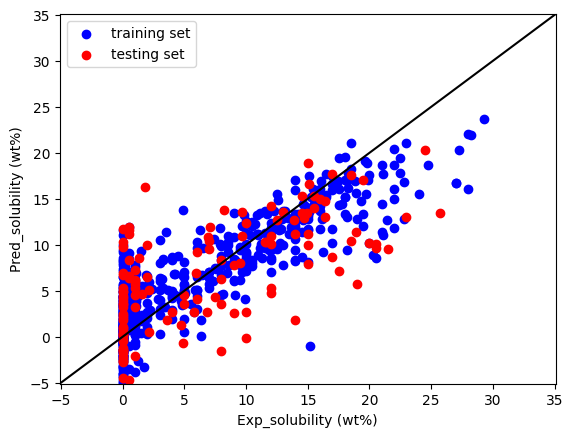

In [7]:
regr = Ridge(random_state=1)
regr.fit(X_train, Y_train)
Y_test_pred = regr.predict(X_test)
Y_train_pred = regr.predict(X_train)
r2_test = sklearn.metrics.r2_score(Y_test, Y_test_pred)
r2_train = sklearn.metrics.r2_score(Y_train, Y_train_pred)
mse_test = mean_squared_error(Y_test, Y_test_pred)
plt.figure()
plt.xlabel("Exp_solubility (wt%)")
plt.ylabel("Pred_solubility (wt%)")
plt.plot([-5.1, 35.1], [-5.1, 35.1], c='black')
plt.scatter(Y_train, Y_train_pred, c='blue', label='training set')
plt.scatter(Y_test, Y_test_pred, c='red', label='testing set')
plt.xlim([-5.1, 35.1])
plt.ylim([-5.1, 35.1])
plt.legend()
print('R^2_test=%f'%r2_test)
print('mse_test=%f'%mse_test)

7. Artificial neural network (ANN) model

In [8]:
keras.utils.set_random_seed(1)
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
model = keras.models.Sequential()
model.add(keras.layers.Dense(units=759, input_shape=(None, 759), activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(units=759, activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(units=1))
model.compile(loss='MSE', optimizer=tf.keras.optimizers.Adam(0.0001))
model.fit(X_train, Y_train, epochs=7000)

Epoch 1/7000
17/17 [==============================] - 1s 13ms/step - loss: 9794756.0000
Epoch 2/7000
17/17 [==============================] - 0s 12ms/step - loss: 29119848.0000
Epoch 3/7000
17/17 [==============================] - 0s 12ms/step - loss: 566709632.0000
Epoch 4/7000
17/17 [==============================] - 0s 12ms/step - loss: 97841472.0000
Epoch 5/7000
17/17 [==============================] - 0s 12ms/step - loss: 453182112.0000
Epoch 6/7000
17/17 [==============================] - 0s 12ms/step - loss: 5160714.0000
Epoch 7/7000
17/17 [==============================] - 0s 13ms/step - loss: 171483136.0000
Epoch 8/7000
17/17 [==============================] - 0s 12ms/step - loss: 494711264.0000
Epoch 9/7000
17/17 [==============================] - 0s 12ms/step - loss: 276312128.0000
Epoch 10/7000
17/17 [==============================] - 0s 12ms/step - loss: 253785664.0000
Epoch 11/7000
17/17 [==============================] - 0s 12ms/step - loss: 817067904.0000
Epoch 12/7000


KeyboardInterrupt: 

17/17 [==============================] - 0s 1ms/step
R^2_test=0.564002
mse_test=22.526243


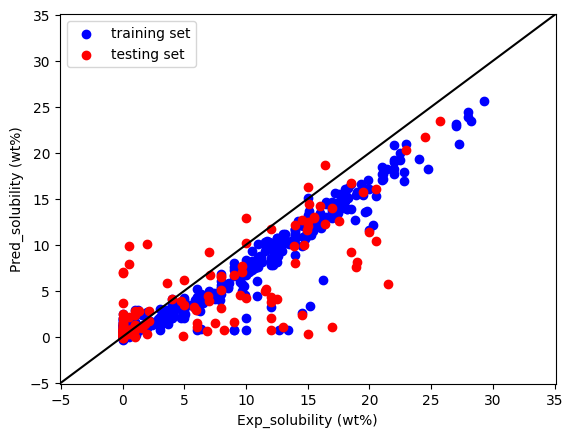

In [9]:
Y_test_pred = model.predict(X_test)
Y_train_pred = model.predict(X_train)
r2_test = sklearn.metrics.r2_score(Y_test, Y_test_pred)
r2_train = sklearn.metrics.r2_score(Y_train, Y_train_pred)
mse_test = mean_squared_error(Y_test, Y_test_pred)
plt.figure()
plt.xlabel("Exp_solubility (wt%)")
plt.ylabel("Pred_solubility (wt%)")
plt.plot([-5.1, 35.1], [-5.1, 35.1], c='black')
plt.scatter(Y_train, Y_train_pred, c='blue', label='training set')
plt.scatter(Y_test, Y_test_pred, c='red', label='testing set')
plt.xlim([-5.1, 35.1])
plt.ylim([-5.1, 35.1])
plt.legend()
print('R^2_test=%f'%r2_test)
print('mse_test=%f'%mse_test)

## Training models on data points with water content less than 1%

1. Read dataset

In [10]:
df = pd.read_csv('dataset_for_cellulose_solubility_ML_model_water_content_less_1%.csv')
smis = list(df.loc[:, 'smiles'])
cation = list(df.loc[:, 'cation'])
anion = list(df.loc[:, 'anion'])
Ts = list(df.loc[:, 'T'])
Crystal = list(df.loc[:, 'cellulose_crystal'])
Crystal_avicel = []
Crystal_MCC = []
Crystal_cellulose = []
for item in Crystal:
    if item == 'Avicel':
        Crystal_avicel.append(1)
        Crystal_MCC.append(0)
        Crystal_cellulose.append(0)
    
    elif item == 'MCC':
        Crystal_avicel.append(0)
        Crystal_MCC.append(1)
        Crystal_cellulose.append(0)
        
    elif item == 'cellulose':
        Crystal_avicel.append(0)
        Crystal_MCC.append(0)
        Crystal_cellulose.append(1)
        
heating_time = list(df.loc[:,'heating_time'])
Ys = list(df.loc[:, 'solv'])

2. Calculate descriptors

In [11]:
def getMolDescriptors(smi):
    mol = Chem.MolFromSmiles(smi)
    res = []
    for nm, fn in Descriptors._descList:
        res.append(fn(mol))
    return res
def smiles_to_MACCS(smi): 
    mol = Chem.MolFromSmiles(smi)
    fp = AllChem.GetMACCSKeysFingerprint(mol)
    fp = np.array(fp, float)
    return fp
Des_cation = np.array([getMolDescriptors(c) for c in cation])
Des_anion = np.array([getMolDescriptors(a) for a in anion])
fp_anion = np.array([smiles_to_MACCS(a) for a in anion])
fp_cation = np.array([smiles_to_MACCS(c) for c in cation])
fp_mol = np.array([smiles_to_MACCS(s) for s in smis])
X = np.c_[fp_cation, Des_cation, fp_anion, Des_anion, Ts, heating_time, Crystal_avicel, Crystal_MCC, Crystal_cellulose]
Y = np.array(Ys).reshape(len(Ys), 1)

3. Split traning set and testing set

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

4. Random forest (RF) regression

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


R^2_test=0.864433
mse_test=8.970935


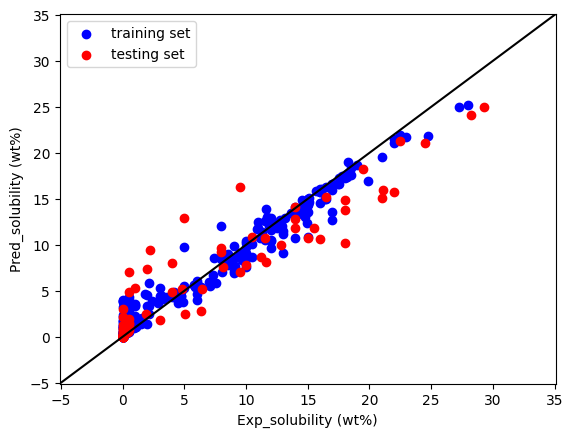

In [13]:
regr = RandomForestRegressor(random_state=1)
regr.fit(X_train, Y_train)
Y_test_pred = regr.predict(X_test)
Y_train_pred = regr.predict(X_train)
r2_test = sklearn.metrics.r2_score(Y_test, Y_test_pred)
r2_train = sklearn.metrics.r2_score(Y_train, Y_train_pred)
mse_test = mean_squared_error(Y_test, Y_test_pred)
plt.figure()
plt.xlabel("Exp_solubility (wt%)")
plt.ylabel("Pred_solubility (wt%)")
plt.plot([-5.1, 35.1], [-5.1, 35.1], c='black')
plt.scatter(Y_train, Y_train_pred, c='blue', label='training set')
plt.scatter(Y_test, Y_test_pred, c='red', label='testing set')
plt.xlim([-5.1, 35.1])
plt.ylim([-5.1, 35.1])
plt.legend()
print('R^2_test=%f'%r2_test)
print('mse_test=%f'%mse_test)

5. Extreme gradient boosting (XGBoost) regression

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().


R^2_test=0.850375
mse_test=9.901146


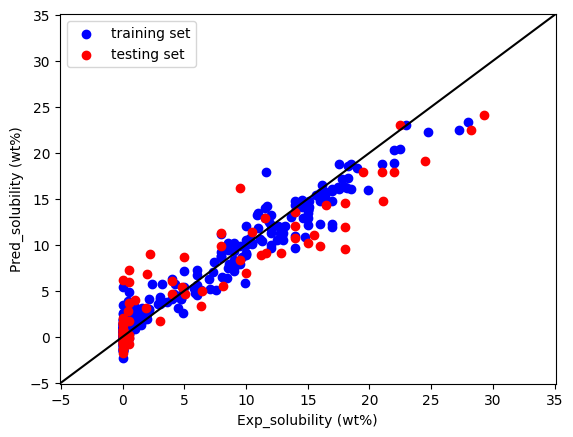

In [14]:
regr = GradientBoostingRegressor(random_state=1)
regr.fit(X_train, Y_train)
Y_test_pred = regr.predict(X_test)
Y_train_pred = regr.predict(X_train)
r2_test = sklearn.metrics.r2_score(Y_test, Y_test_pred)
r2_train = sklearn.metrics.r2_score(Y_train, Y_train_pred)
mse_test = mean_squared_error(Y_test, Y_test_pred)
plt.figure()
plt.xlabel("Exp_solubility (wt%)")
plt.ylabel("Pred_solubility (wt%)")
plt.plot([-5.1, 35.1], [-5.1, 35.1], c='black')
plt.scatter(Y_train, Y_train_pred, c='blue', label='training set')
plt.scatter(Y_test, Y_test_pred, c='red', label='testing set')
plt.xlim([-5.1, 35.1])
plt.ylim([-5.1, 35.1])
plt.legend()
print('R^2_test=%f'%r2_test)
print('mse_test=%f'%mse_test)

6. Ridge regression

R^2_test=0.659019
mse_test=22.563815


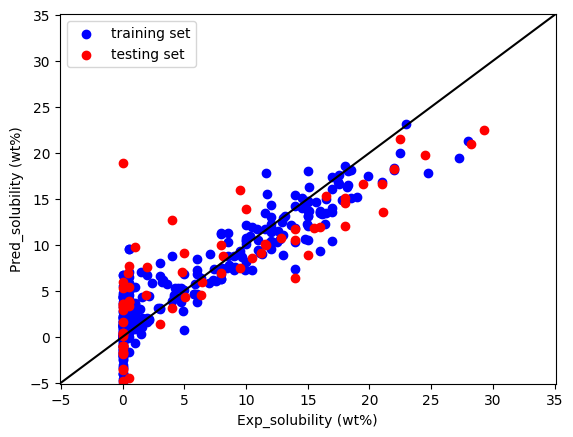

In [15]:
regr = Ridge(random_state=1)
regr.fit(X_train, Y_train)
Y_test_pred = regr.predict(X_test)
Y_train_pred = regr.predict(X_train)
r2_test = sklearn.metrics.r2_score(Y_test, Y_test_pred)
r2_train = sklearn.metrics.r2_score(Y_train, Y_train_pred)
mse_test = mean_squared_error(Y_test, Y_test_pred)
plt.figure()
plt.xlabel("Exp_solubility (wt%)")
plt.ylabel("Pred_solubility (wt%)")
plt.plot([-5.1, 35.1], [-5.1, 35.1], c='black')
plt.scatter(Y_train, Y_train_pred, c='blue', label='training set')
plt.scatter(Y_test, Y_test_pred, c='red', label='testing set')
plt.xlim([-5.1, 35.1])
plt.ylim([-5.1, 35.1])
plt.legend()
print('R^2_test=%f'%r2_test)
print('mse_test=%f'%mse_test)

7. Artificial neural network (ANN) model

In [16]:
keras.utils.set_random_seed(1)
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
model = keras.models.Sequential()
model.add(keras.layers.Dense(units=759, input_shape=(None, 759), activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(units=759, activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(units=1))
model.compile(loss='MSE', optimizer=tf.keras.optimizers.Adam(0.0001))
model.fit(X_train, Y_train, epochs=7000)

Epoch 1/7000
10/10 [==============================] - 0s 6ms/step - loss: 146463456.0000
Epoch 2/7000
10/10 [==============================] - 0s 4ms/step - loss: 521418848.0000
Epoch 3/7000
10/10 [==============================] - 0s 5ms/step - loss: 7054614528.0000
Epoch 4/7000
10/10 [==============================] - 0s 5ms/step - loss: 664111360.0000
Epoch 5/7000
10/10 [==============================] - 0s 4ms/step - loss: 3006166016.0000
Epoch 6/7000
10/10 [==============================] - 0s 5ms/step - loss: 1034763456.0000
Epoch 7/7000
10/10 [==============================] - 0s 5ms/step - loss: 961562240.0000
Epoch 8/7000
10/10 [==============================] - 0s 4ms/step - loss: 1691671424.0000
Epoch 9/7000
10/10 [==============================] - 0s 4ms/step - loss: 963263168.0000
Epoch 10/7000
10/10 [==============================] - 0s 5ms/step - loss: 7707523072.0000
Epoch 11/7000
10/10 [==============================] - 0s 4ms/step - loss: 317356384.0000
Epoch 12/7000


10/10 [==============================] - 0s 1ms/step
R^2_test=0.874130
mse_test=8.329200


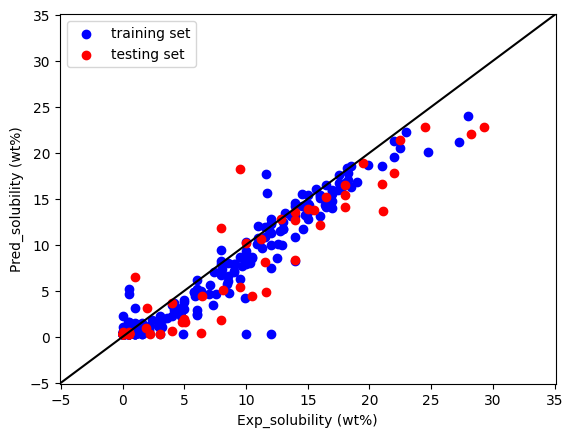

In [17]:
Y_test_pred = model.predict(X_test)
Y_train_pred = model.predict(X_train)
r2_test = sklearn.metrics.r2_score(Y_test, Y_test_pred)
r2_train = sklearn.metrics.r2_score(Y_train, Y_train_pred)
mse_test = mean_squared_error(Y_test, Y_test_pred)
plt.figure()
plt.xlabel("Exp_solubility (wt%)")
plt.ylabel("Pred_solubility (wt%)")
plt.plot([-5.1, 35.1], [-5.1, 35.1], c='black')
plt.scatter(Y_train, Y_train_pred, c='blue', label='training set')
plt.scatter(Y_test, Y_test_pred, c='red', label='testing set')
plt.xlim([-5.1, 35.1])
plt.ylim([-5.1, 35.1])
plt.legend()
print('R^2_test=%f'%r2_test)
print('mse_test=%f'%mse_test)

Interpret model using SHAP

In [ ]:
explainer = shap.Explainer(model.predict, X_train, seed=1)
shap_values = explainer(X_test, max_evals=2000)

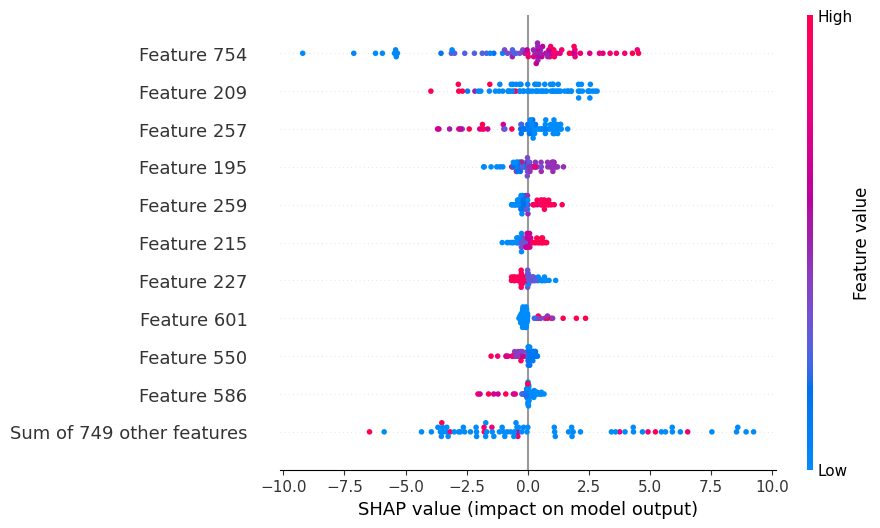

In [19]:
shap.plots.beeswarm(shap_values, max_display=11)

## Cross validation

1. Random forest (RF) regression

In [9]:
kf = KFold(n_splits=10)
pred = np.zeros(len(Y))
for train_index, test_index in kf.split(X, Y):
    regr = RandomForestRegressor(random_state=1)
    regr.fit(X[train_index], Y[train_index])
    pred[test_index] = regr.predict(X[test_index])

print("R2: ", r2_score(Y, pred))
print("MSE: ", mean_squared_error(Y, pred))

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the

R2:  0.5138817612976045
MSE:  25.736173397696


2. Extreme gradient boosting (XGBoost) regression

In [10]:
kf = KFold(n_splits=10)
pred = np.zeros(len(Y))
for train_index, test_index in kf.split(X, Y):
    regr = GradientBoostingRegressor(random_state=1)
    regr.fit(X[train_index], Y[train_index])
    pred[test_index] = regr.predict(X[test_index])

print("R2: ", r2_score(Y, pred))
print("MSE: ", mean_squared_error(Y, pred))

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please cha

R2:  0.48352861060563834
MSE:  27.343136245788358


3. Ridge regression

In [22]:
kf = KFold(n_splits=10)
pred = np.zeros(len(Y)).reshape(-1, 1)
for train_index, test_index in kf.split(X, Y):
    regr = Ridge(random_state=1)
    regr.fit(X[train_index], Y[train_index])
    pred[test_index] = regr.predict(X[test_index])

print("R2: ", r2_score(Y, pred))
print("MSE: ", mean_squared_error(Y, pred))

R2:  0.6028661996556202
MSE:  19.939158429886266


4. Artificial neural network (ANN) models

Please run python script: cross_validation_for_ANN_model.py
```bash
python cross_validation_for_ANN_model.py
```

## Applicability  domain

In [23]:
def identify_domian(training_set, test_IL):
    """
    A function to identifiy whether a test ionic liquid of interest located in the applicabilty domain of the training set.
    training_set: the descriptors numpy array of training set
    test_IL: the descriptors numpy array of IL to be tested
    """
    X_average = np.mean(training_set, axis=0)
    segma = np.std(training_set, axis=0)
    for i in range(len(segma)):
        if segma[i] == 0:
            segma[i] = 1
    S_k = np.abs(test_IL - X_average) / segma 
    if S_k.max() <= 3:
        ans = S_k.max()
    if S_k.min() > 3:
        ans = S_k.min()
    if S_k.max() > 3 and S_k.min() <= 3:
        ans = S_k.mean() + 1.28 * S_k.std()
    return ans